### Simulating a single electrode for multiple participants
- Simulating central line (Cz to T7) for 10 participants
- Calculate power spectra for each participant and then average the power spectra together
- Plot the Spectral Model for the average power spectra of the 10 participants
- Logic can be applied to all electrodes based on correlations between the specified electrode and Cz and the number of participants increased

#### Imports

In [6]:
# Imports required for functionality 
import numpy as np
from matplotlib import pyplot 
import matplotlib.pyplot as plt

from neurodsp.utils import create_times
from neurodsp.sim import sim_oscillation, set_random_seed, sim_combined
from neurodsp.plts import plot_time_series, plot_power_spectra
from neurodsp.spectral import compute_spectrum_welch

from simulate_cz_signal import generate_cz_signal

from specparam import SpectralGroupModel
from specparam.plts import plot_spectra

#### Simulating EEG-like signal for multiple participants 

In [16]:
n_ppts = 10
electrodes = ['Cz', 'C1', 'C3', 'C5', 'T7']
corr_factors = {
    'Cz': 1.0,   # reference electrode
    'C1': 0.8,   # adjacent
    'C3': 0.6,   # farther
    'C5': 0.4,    # more distant
    'T7' : 0.2   # most distant
}
group_powers = {elect: [] for elect in electrodes}

In [18]:
for p in range(n_ppts):

    # Generate Cz for this participant
    cz_signal = generate_cz_signal(seed=256, n_seconds=10, s_rate=250)
    electrode_signals = {}

    for elect, rho in corr_factors.items():
        if elect == 'Cz':
            electrode_signals[elect] = cz_signal
        else:
            sigma_source = np.std(cz_signal)
            noise_std = np.sqrt((1 - rho**2) / rho**2) * sigma_source
            noise = noise_std * np.random.randn(len(cz_signal))
            electrode_signals[elect] = rho * cz_signal + noise

    # Compute spectra and store powers
    for elect in electrodes:
        sig = electrode_signals[elect]
        freqs, powers = compute_spectrum_welch(sig, fs=250)
        group_powers[elect].append(powers)

    all_powers= np.array(group_powers[elect])

C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\data\data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)



	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Fitting model across 11 power spectra.
                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (11 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-125 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
          

C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\data\data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)


                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (11 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-125 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                         offset   - Min:  -0.77, Max:  -0.77, Mean: -0.77                         
                         exponent - Min:   0.04, Max:   0.04, Mean:  0.04                         
                                                                                                  
          

C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\data\data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)


                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (11 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-125 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                         offset   - Min:  -0.77, Max:  -0.77, Mean: -0.77                         
                         exponent - Min:   0.04, Max:   0.04, Mean:  0.04                         
                                                                                                  
          

C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\data\data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)


                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (11 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-125 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                         offset   - Min:  -0.77, Max:  -0.77, Mean: -0.77                         
                         exponent - Min:   0.04, Max:   0.04, Mean:  0.04                         
                                                                                                  
          

C:\Users\chloe\OneDrive\Documents\Anaconda\envs\diss_worksheet\Lib\site-packages\specparam\data\data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)


                                                                                                  
                            GROUP SPECTRAL MODEL RESULTS (11 spectra)                             
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 1-125 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                         offset   - Min:  -0.77, Max:  -0.77, Mean: -0.77                         
                         exponent - Min:   0.04, Max:   0.04, Mean:  0.04                         
                                                                                                  
          

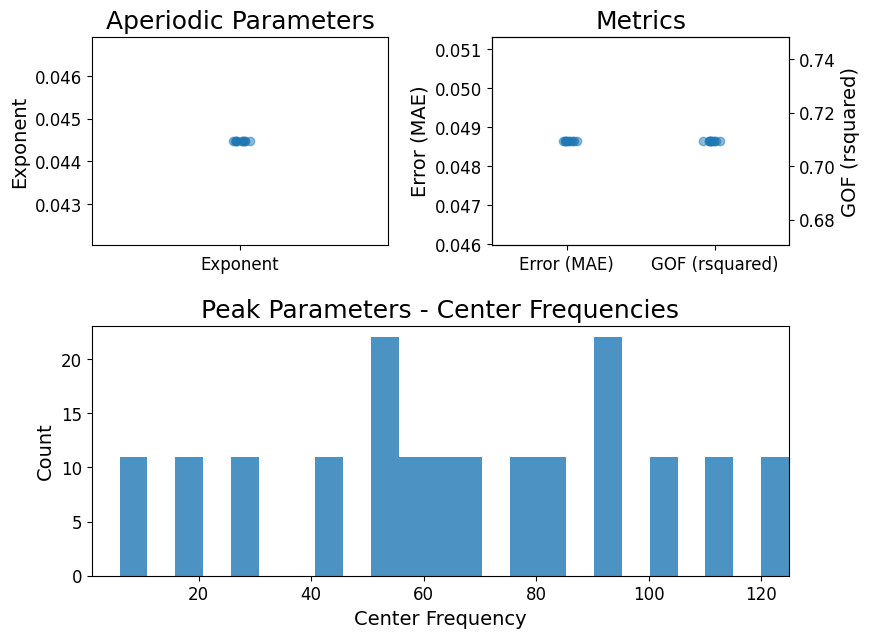

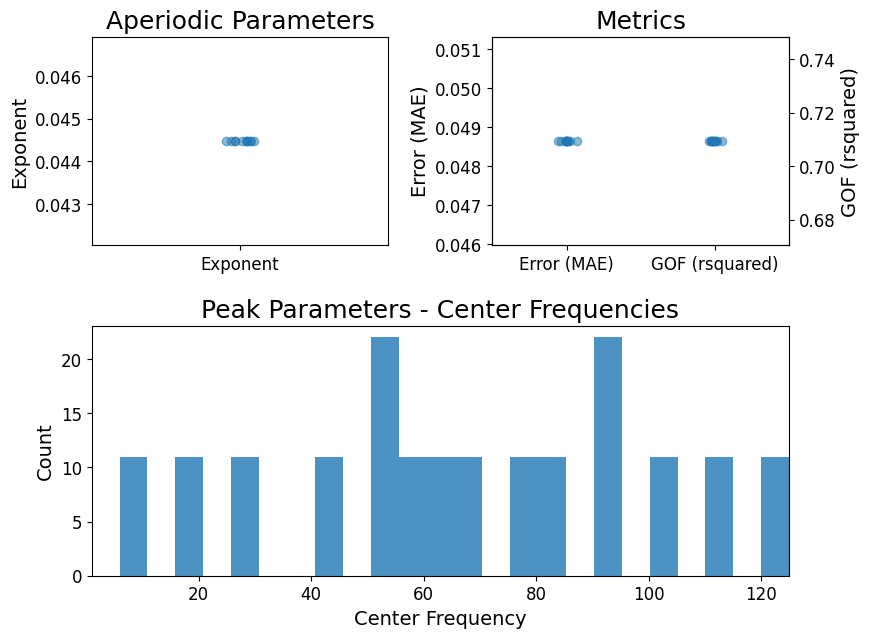

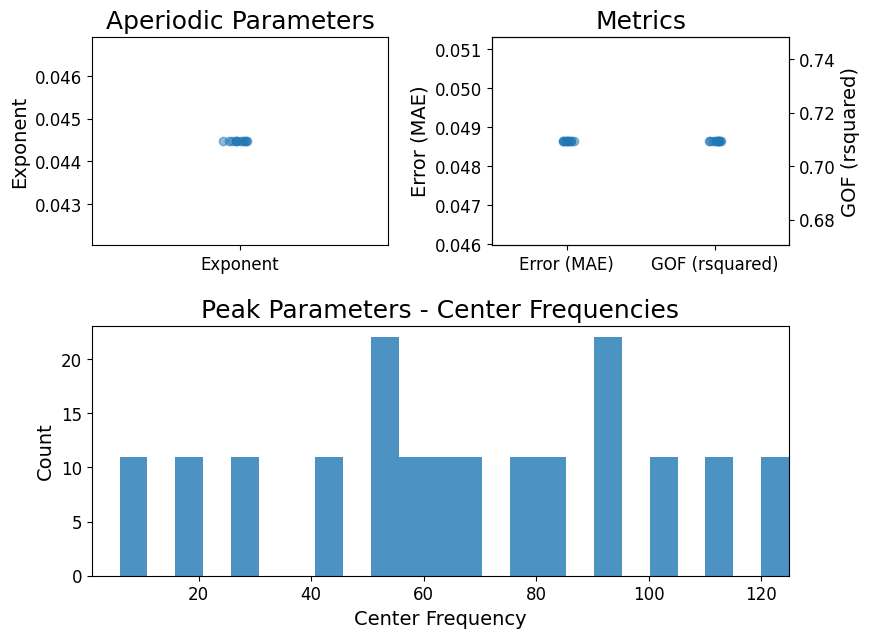

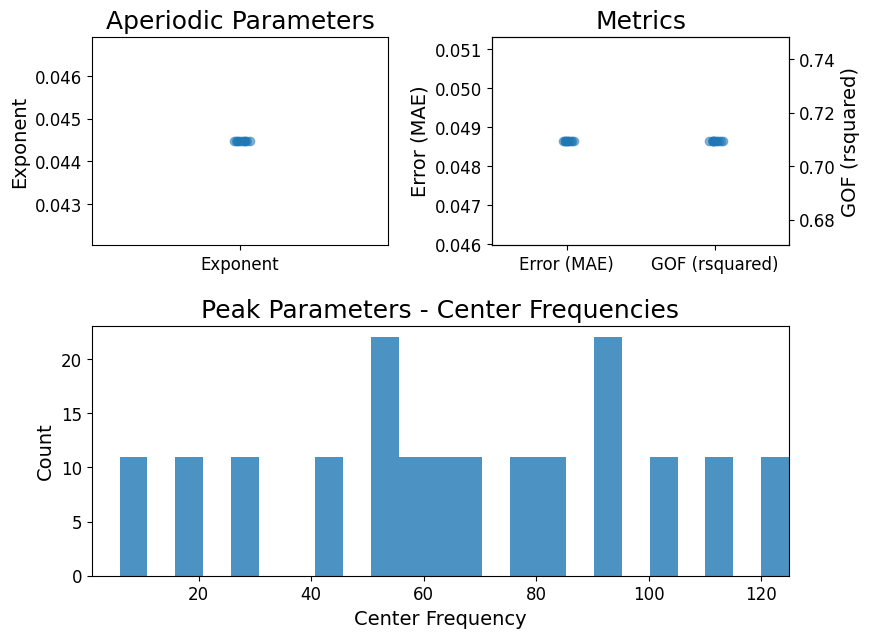

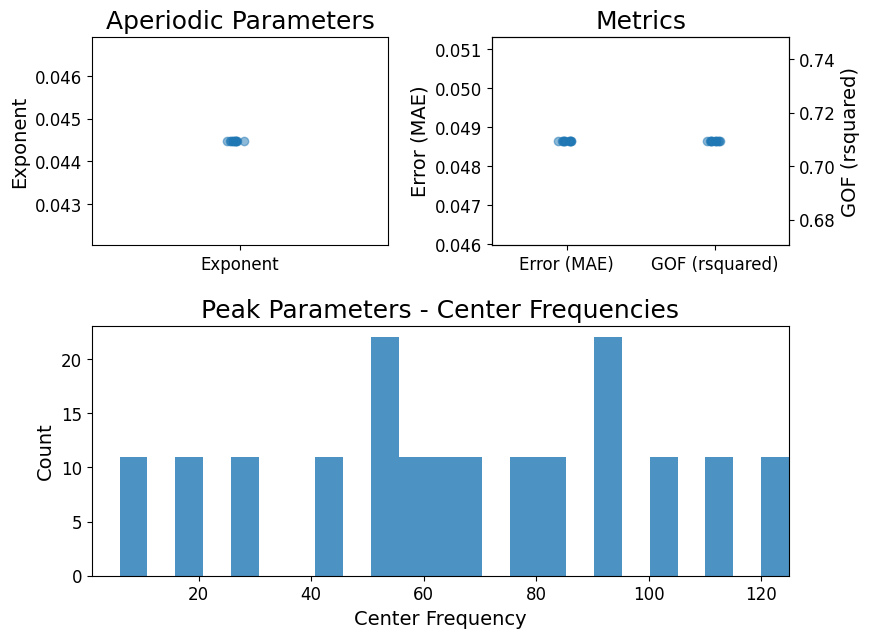

In [25]:
for i, elect in enumerate(electrodes): 
    fg = SpectralGroupModel() 
    fg.fit(freqs, all_powers) 
    fg.print_results() 
    fg.plot()
